# Variational quantum time-propagation for KdV

Team: Andrei Poliakov, Kyro Jeremy Gibling, Nadav Carmel, Pak Tik, Sahil Ugale

Second, independent pathway for KdV, alongside Carleman+QSVT (`KdV_Carlemann_qiskit.ipynb`). That
pathway costs ~1-2.6M gates for a toy N=5 problem (simulator-only); this one is shallow enough to
be hardware-relevant.

Instead of linearizing via Carleman, the field is amplitude-encoded into a circuit and stepped
forward by minimizing a Hadamard-test cost function each timestep (Lubasch et al., Phys. Rev. A
101, 010301 (2020)). Ansatz, shift operator, and Hadamard-test circuits are derived from scratch in
`kdv.py`, not adapted from another implementation — including a two-register
construction for the nonlinear term, since it's a trilinear overlap rather than a plain overlap.
Ansatz is a standard 3-parameter real-amplitude circuit with full expressivity (fits arbitrary
target states to ~1e-13 residual).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

from kdv import ansatz, get_state, get_expval_ideal, get_expval_shots, kdv_cost
from discretization import periodic_D3, construct_F2_periodic


## Problem setup

N=4 grid points. delta chosen (as in the Carleman notebook) for a dispersion/convection ratio
~4 — the genuinely-nonlinear regime found in `kdv_convergence_study.py`. IC is a non-single-mode
profile since single Fourier modes have a zero discrete nonlinear term at N=4.


In [2]:
n = 2
N = 2 ** n
x = np.linspace(0, 1, N, endpoint=False)
dx = x[1] - x[0]

u0 = np.array([0.0, -0.5, 1 / np.sqrt(2), 0.5])
u0 = u0 / np.linalg.norm(u0)
delta = 0.0625
dt = 0.01
n_steps = 4

D3 = periodic_D3(N, dx)
F2 = -1 / (2 * dx) * construct_F2_periodic(N)

lin = np.linalg.norm(delta * (D3 @ u0))
quad = np.linalg.norm(F2 @ np.kron(u0, u0))
print(f"u0 = {u0}")
print(f"linear/nonlinear norm ratio = {lin/quad:.2f}  (target ~4, matching the convergent window "
      f"found in kdv_convergence_study.py)")


u0 = [ 0.         -0.5         0.70710678  0.5       ]
linear/nonlinear norm ratio = 4.00  (target ~4, matching the convergent window found in kdv_convergence_study.py)


## Encoding the initial state


In [3]:
def init_loading(theta, target):
    v = np.real(Statevector(ansatz(theta)).data)
    return np.sum((v - target) ** 2)


best = None
for trial in range(20):
    theta0 = np.random.default_rng(trial).random(3) * 2 * np.pi
    res = sp.optimize.minimize(init_loading, theta0, args=(u0,), method="BFGS")
    if best is None or res.fun < best.fun:
        best = res

theta0_full = np.concatenate(([1.0], best.x))
print(f"encoding fit residual: {best.fun:.2e}")
print(f"decoded state: {np.round(get_state(theta0_full), 4)}")
print(f"target u0:     {np.round(u0, 4)}")


encoding fit residual: 3.03e-15
decoded state: [ 0.     -0.5     0.7071  0.5   ]
target u0:     [ 0.     -0.5     0.7071  0.5   ]


## Timestep update (ideal, no shot noise)

`kdv_cost` builds the Hadamard-test overlaps and returns the cost, minimized with COBYLA
(warm-started from the previous timestep).


In [4]:
def optimize_step(theta_old, seed_offset):
    def objective(theta_new):
        cost, _ = kdv_cost(theta_new, theta_old, dt, dx, delta, get_expval_ideal)
        return cost

    best_new = None
    for trial in range(10):
        guess = theta_old + np.random.default_rng(seed_offset + trial).normal(scale=0.05, size=4)
        res = sp.optimize.minimize(objective, guess, method="COBYLA", options={"maxiter": 800})
        if best_new is None or res.fun < best_new.fun:
            best_new = res
    return best_new.x, best_new.fun


f_classical = u0.copy()
theta = theta0_full.copy()
quantum_states = [get_state(theta)]
classical_states = [f_classical.copy()]
rel_errors = []

for step in range(n_steps):
    f_next_classical = f_classical + dt * (-delta * (D3 @ f_classical) + F2 @ np.kron(f_classical, f_classical))
    theta, cost = optimize_step(theta, seed_offset=300 + 10 * step)
    decoded = get_state(theta)
    rel_err = np.linalg.norm(decoded - f_next_classical) / np.linalg.norm(f_next_classical)
    rel_errors.append(rel_err)
    print(f"step {step+1}: cost={cost:.6f}  rel. L2 error vs. classical={rel_err:.5f}")
    f_classical = f_next_classical
    quantum_states.append(decoded)
    classical_states.append(f_classical.copy())

quantum_states = np.array(quantum_states)
classical_states = np.array(classical_states)


step 1: cost=-0.983969  rel. L2 error vs. classical=0.00003


step 2: cost=-0.968244  rel. L2 error vs. classical=0.00004


step 3: cost=-0.953240  rel. L2 error vs. classical=0.00006


step 4: cost=-0.939389  rel. L2 error vs. classical=0.00006


## Results

Tracks the exact-ODE reference to optimizer precision at every step.


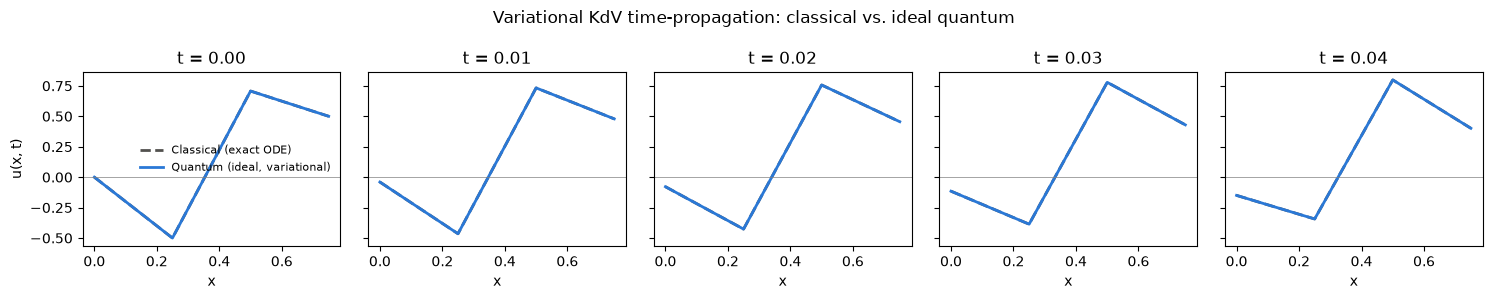

In [5]:
fig, axes = plt.subplots(1, n_steps + 1, figsize=(3.0 * (n_steps + 1), 3.0), sharey=True)
timesteps = np.arange(n_steps + 1) * dt
for i, ax in enumerate(axes):
    ax.plot(x, classical_states[i], "--", color="#52514e", lw=2, label="Classical (exact ODE)")
    ax.plot(x, quantum_states[i], "-", color="#2a78d6", lw=2, label="Quantum (ideal, variational)")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(f"t = {timesteps[i]:.2f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("u(x, t)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Variational KdV time-propagation: classical vs. ideal quantum")
fig.tight_layout()


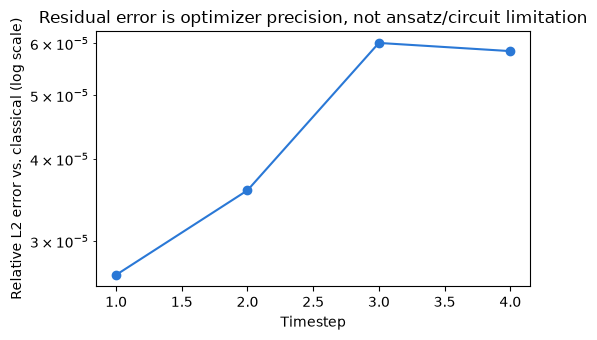

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(np.arange(1, n_steps + 1), rel_errors, "o-", color="#2a78d6")
ax.set_yscale("log")
ax.set_xlabel("Timestep")
ax.set_ylabel("Relative L2 error vs. classical (log scale)")
ax.set_title("Residual error is optimizer precision, not ansatz/circuit limitation")
fig.tight_layout()


## Path to real hardware

Not run here. Before spending QPU time: transpile to a real backend's gate set and check 2-qubit
gate counts (Hadamard-test circuits are connectivity-sensitive — IBM's limited connectivity is a
real risk, not hypothetical), then dry-run against a noise model before committing.
